In [ ]:
# Install required packages (if needed)
!pip install tensorflow numpy pandas scikit-learn matplotlib seaborn

# Import libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D
from tensorflow.keras.layers import Bidirectional, GRU, Dense, Dropout, Concatenate, Flatten
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Load your dataset

df = pd.read_csv('phishing_dataset_final.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset Shape: (1602068, 2)

First few rows:


,url,label
0,direccte.gouv.fr,1
1,666dvp9xue.no-ip.org/secure/login?user=oqjyor,0
2,articles.latimes.com/keyword/royce-clayton,1
3,http://157.245.141.253,0
4,flickr.com/photos/f-p/3629461003,1


In [ ]:
print(f"\nDataset Info:")
print(df.info())

print(f"\nClass Distribution:")
print(df['label'].value_counts())
print(f"\nClass Balance: {df['label'].value_counts(normalize=True)}")

# Check for missing values
print(f"\nMissing Values:")
df.isnull().sum()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1602068 entries, 0 to 1602067
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   url     1602068 non-null  object
 1   label   1602068 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 24.4+ MB
None

Class Distribution:
label
1    831631
0    770437
Name: count, dtype: int64

Class Balance: label
1    0.519098
0    0.480902
Name: proportion, dtype: float64

Missing Values:


,0
url,0
label,0


In [ ]:
# 1. Process URL Features (Tokenizer)
MAX_URL_LENGTH = 200
VOCAB_SIZE = 100

tokenizer = Tokenizer(char_level=True, lower=True, oov_token='<OOV>')

def prepare_urls(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    return pad_sequences(sequences, maxlen=MAX_URL_LENGTH, padding='post', truncating='post')

In [ ]:
url = df['url'].astype(str).values
labels = df['label'].values

# Fit the tokenizer on the training URLs to build the character vocabulary
tokenizer.fit_on_texts(url)

# 1. Split into Train (70%) and Temp (30%)
# stratify=labels ensures class balance is maintained
X_url_train_raw, X_url_temp, y_train, y_temp = train_test_split(
    url,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

# 2. Split Temp into Validation (15%) and Test (15%)
# stratify=y_temp ensures balance in the remaining samples
X_url_val_raw, X_url_test_raw, y_val, y_test = train_test_split(
    X_url_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Tokenize the URL data
X_train = prepare_urls(X_url_train_raw)
X_val   = prepare_urls(X_url_val_raw)
X_test  = prepare_urls(X_url_test_raw)

print(f"Stratified Train Labels: {np.bincount(y_train) / len(y_train)}")
print(f"Stratified Val Labels:   {np.bincount(y_val) / len(y_val)}")

Stratified Train Labels: [0.48090191 0.51909809]
Stratified Val Labels:   [0.48089967 0.51910033]


In [ ]:
import pickle

# Define the file path where you want to save the tokenizer
tokenizer_path = 'tokenizer.pkl'

# Save the tokenizer to a file
with open(tokenizer_path, 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("Tokenizer successfully saved to:", tokenizer_path)

Tokenizer successfully saved to: tokenizer.pkl


In [ ]:
EMBEDDING_DIM = 64

def build_url_only_model(max_length, vocab_size, embedding_dim):
    # URL Input
    url_input = Input(shape=(max_length,), name='url_input')

    # Character Embedding
    embedding = Embedding(input_dim=vocab_size,
                          output_dim=embedding_dim,
                          name='char_embedding')(url_input)

    # Parallel CNN layers
    conv1 = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(embedding)
    conv1 = MaxPooling1D(pool_size=2)(conv1)

    conv2 = Conv1D(filters=128, kernel_size=5, activation='relu', padding='same')(embedding)
    conv2 = MaxPooling1D(pool_size=2)(conv2)

    conv3 = Conv1D(filters=128, kernel_size=7, activation='relu', padding='same')(embedding)
    conv3 = MaxPooling1D(pool_size=2)(conv3)

    # Concatenate CNN outputs
    cnn_concat = Concatenate()([conv1, conv2, conv3])

    # BiGRU Layer
    bigru = Bidirectional(GRU(128, return_sequences=False, dropout=0.2))(cnn_concat)

    # Final Dense Layers (Processing BiGRU output directly)
    dense1 = Dense(256, activation='relu')(bigru)
    dense1 = Dropout(0.3)(dense1)

    dense2 = Dense(128, activation='relu')(dense1)
    dense2 = Dropout(0.2)(dense2)

    # Output Layer
    output = Dense(1, activation='sigmoid', name='output')(dense2)

    model = Model(inputs=url_input, outputs=output)
    return model

# Build the simplified model
model = build_url_only_model(
    max_length=MAX_URL_LENGTH,
    vocab_size=len(tokenizer.word_index) + 1,
    embedding_dim=EMBEDDING_DIM
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ url_input           │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_embedding      │ (None, 200, 64)   │      3,904 │ url_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 200, 128)  │     24,704 │ char_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 200, 128)  │     41,088 │ char_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 200, 128)  │     57,472 │ char_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 100, 128)  │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 100, 128)  │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 100, 128)  │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100, 384)  │          0 │ max_pooling1d[0]… │
│ (Concatenate)       │                   │            │ max_pooling1d_1[… │
│                     │                   │            │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 256)       │    394,752 │ concatenate[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     65,792 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 620,737 (2.37 MB)

 Trainable params: 620,737 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile (Keep same metrics)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall'), keras.metrics.AUC(name='auc')]
)

In [ ]:
# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_phishing_model.h5',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

callbacks = [early_stopping, model_checkpoint, reduce_lr]

print("Callbacks configured!")

Callbacks configured!


In [ ]:
# Train the model
history = model.fit(
    X_train, # Single input
    y_train,
    batch_size=256,
    epochs=20,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
4381/4381 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9359 - auc: 0.9808 - loss: 0.1576 - precision: 0.9258 - recall: 0.9534
Epoch 1: val_auc improved from None to 0.99576, saving model to best_phishing_model.h5



Epoch 1: finished saving model to best_phishing_model.h5
4381/4381 ━━━━━━━━━━━━━━━━━━━━ 292s 65ms/step - accuracy: 0.9559 - auc: 0.9916 - loss: 0.1119 - precision: 0.9481 - recall: 0.9680 - val_accuracy: 0.9702 - val_auc: 0.9958 - val_loss: 0.0780 - val_precision: 0.9653 - val_recall: 0.9777 - learning_rate: 0.0010
Epoch 2/20
4380/4381 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9705 - auc: 0.9958 - loss: 0.0768 - precision: 0.9642 - recall: 0.9793
Epoch 2: val_auc improved from 0.99576 to 0.99671, saving model to best_phishing_model.h5



Epoch 2: finished saving model to best_phishing_model.h5
4381/4381 ━━━━━━━━━━━━━━━━━━━━ 287s 65ms/step - accuracy: 0.9710 - auc: 0.9959 - loss: 0.0753 - precision: 0.9649 - recall: 0.9797 - val_accuracy: 0.9738 - val_auc: 0.9967 - val_loss: 0.0685 - val_precision: 0.9664 - val_recall: 0.9836 - learning_rate: 0.0010
Epoch 3/20
4380/4381 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9738 - auc: 0.9967 - loss: 0.0675 - precision: 0.9683 - recall: 0.9818
Epoch 3: val_auc improved from 0.99671 to 0.99708, saving model to best_phishing_model.h5



Epoch 3: finished saving model to best_phishing_model.h5
4381/4381 ━━━━━━━━━━━━━━━━━━━━ 286s 65ms/step - accuracy: 0.9742 - auc: 0.9967 - loss: 0.0670 - precision: 0.9689 - recall: 0.9819 - val_accuracy: 0.9756 - val_auc: 0.9971 - val_loss: 0.0634 - val_precision: 0.9708 - val_recall: 0.9824 - learning_rate: 0.0010
Epoch 4/20
4380/4381 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9761 - auc: 0.9972 - loss: 0.0619 - precision: 0.9715 - recall: 0.9829
Epoch 4: val_auc improved from 0.99708 to 0.99737, saving model to best_phishing_model.h5



Epoch 4: finished saving model to best_phishing_model.h5
4381/4381 ━━━━━━━━━━━━━━━━━━━━ 287s 65ms/step - accuracy: 0.9762 - auc: 0.9972 - loss: 0.0619 - precision: 0.9714 - recall: 0.9830 - val_accuracy: 0.9766 - val_auc: 0.9974 - val_loss: 0.0610 - val_precision: 0.9752 - val_recall: 0.9798 - learning_rate: 0.0010
Epoch 5/20
4380/4381 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9778 - auc: 0.9975 - loss: 0.0577 - precision: 0.9733 - recall: 0.9843
Epoch 5: val_auc did not improve from 0.99737
4381/4381 ━━━━━━━━━━━━━━━━━━━━ 287s 65ms/step - accuracy: 0.9777 - auc: 0.9975 - loss: 0.0581 - precision: 0.9731 - recall: 0.9843 - val_accuracy: 0.9770 - val_auc: 0.9973 - val_loss: 0.0603 - val_precision: 0.9698 - val_recall: 0.9863 - learning_rate: 0.0010
Epoch 6/20
4380/4381 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9791 - auc: 0.9978 - loss: 0.0542 - precision: 0.9749 - recall: 0.9851
Epoch 6: val_auc did not improve from 0.99737
4381/4381 ━━━━━━━━━━━━━━━━━━━━ 287s 66ms/step - ac


Epoch 10: finished saving model to best_phishing_model.h5
4381/4381 ━━━━━━━━━━━━━━━━━━━━ 287s 65ms/step - accuracy: 0.9821 - auc: 0.9983 - loss: 0.0468 - precision: 0.9780 - recall: 0.9878 - val_accuracy: 0.9785 - val_auc: 0.9975 - val_loss: 0.0574 - val_precision: 0.9742 - val_recall: 0.9846 - learning_rate: 0.0010
Epoch 11/20
4380/4381 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9829 - auc: 0.9984 - loss: 0.0449 - precision: 0.9789 - recall: 0.9883
Epoch 11: val_auc did not improve from 0.99752
4381/4381 ━━━━━━━━━━━━━━━━━━━━ 286s 65ms/step - accuracy: 0.9826 - auc: 0.9983 - loss: 0.0454 - precision: 0.9788 - recall: 0.9880 - val_accuracy: 0.9782 - val_auc: 0.9971 - val_loss: 0.0594 - val_precision: 0.9725 - val_recall: 0.9859 - learning_rate: 0.0010
Epoch 12/20
4380/4381 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9837 - auc: 0.9985 - loss: 0.0428 - precision: 0.9800 - recall: 0.9888
Epoch 12: val_auc did not improve from 0.99752
4381/4381 ━━━━━━━━━━━━━━━━━━━━ 286s 65ms/step

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Load the saved model
# Replace 'best_phishing_model.h5' with your actual filename if different
model = tf.keras.models.load_model('best_phishing_model (3).h5')

def predict_url(custom_url):
    # 1. Preprocess the URL using the same tokenizer logic
    seq = tokenizer.texts_to_sequences([custom_url])
    padded = pad_sequences(seq, maxlen=MAX_URL_LENGTH, padding='post', truncating='post')

    # 2. Get prediction
    prediction = model.predict(padded, verbose=0)[0][0]

    # 3. Interpret result
    label = "SAFE" if prediction > 0.5 else "PHISHING"
    confidence = prediction if prediction > 0.5 else (1 - prediction)

    print(f"URL: {custom_url}")
    print(f"Result: {label} ({confidence*100:.2f}% confidence)\n")

# --- Test Cases ---
test_urls = [
    "https://www.jpvoteshop.shop/?vid=001",                         # Clearly Safe
    "http://login-microsoft-verify.com/account",      # Classic Phishing (Look-alike)
    "https://paypal.security-update.net/login",       # Subdomain Phishing
    "https://www.amazon.com/gp/cart/view.html",       # Safe but complex path
    "http://192.168.1.1/login.php",                   # IP based (Often suspicious)
    "https://wellsfargo.com-verification.info",
    "https://careers.cognizant.com/india-en/",
    "https://stcet.ac.in/",
    "https://track.pstmrk.it/3s/1u2j3xc.atoms.world/Oifs/3O-EAQ/AQ/61bbc71f...",
    "https://login-ledger-hardware.pages.dev/",
    "https://gemini-enhancer.pages.dev/",
    "https://amazon-space.com/",
    "https://meta-google.pages.dev/",
    "https://leetcode.com/",
    "https://gate2026.iitg.ac.in/",
    "https://www.npci.org.in/",
    "https://www.iitbbs.ac.in/index.php/list-of-selected-and-wait-listed-candidates-for-m-tech-admission-2024-25ses/"
]

# List of 50 Legitimate URLs for testing
legitimate_test_urls = [
    # Search & Portals
    "https://www.google.com", "https://www.bing.com", "https://www.yahoo.com",
    "https://duckduckgo.com", "https://www.baidu.com", "https://www.yandex.com",
    "https://www.ask.com", "https://www.ecosia.org", "https://www.aol.com", "https://www.msn.com",

    # Social Media & Communication
    "https://www.facebook.com", "https://www.instagram.com", "https://x.com",
    "https://www.linkedin.com", "https://www.reddit.com", "https://www.tiktok.com",
    "https://www.pinterest.com", "https://www.whatsapp.com", "https://telegram.org", "https://discord.com",

    # Tech & Development
    "https://github.com", "https://stackoverflow.com", "https://www.microsoft.com",
    "https://www.apple.com", "https://www.nvidia.com", "https://aws.amazon.com",
    "https://cloud.google.com", "https://www.ibm.com", "https://www.oracle.com", "https://www.cloudflare.com",

    # News & Reference
    "https://en.wikipedia.org/wiki/Main_Page", "https://www.nytimes.com", "https://www.bbc.com",
    "https://www.cnn.com", "https://www.forbes.com", "https://www.quora.com",
    "https://medium.com", "https://www.reuters.com", "https://www.theguardian.com", "https://www.bloomberg.com",

    # E-commerce, Finance & Education
    "https://www.amazon.com", "https://www.ebay.com", "https://www.walmart.com",
    "https://www.paypal.com", "https://www.chase.com", "https://www.bankofamerica.com",
    "https://www.wellsfargo.com", "https://www.coursera.org", "https://www.khanacademy.org", "https://www.stripe.com"
]

# URLs extracted from your current PhishTank view
phishtank_test_urls = [
    "http://rxss.cn",
    "https://flere.network/",
    "https://dhl-app.skydropx.com/users/sign_in",
    "https://whatsappwebb-6fi.pages.dev/",
    "https://whatsappwhatsapp345.pages.dev/",
    "https://ledger-staking.pages.dev/",
    "https://instagram-marke.com/",
    "https://usps-store.com/",
    "https://m.zh-telegramxz.com.cn/",
    "https://myeetherwalet.firebaseapp.com/",
    "https://pay-for-okx-web3-usdt-trc20-0000000014.pages.dev/",
    "https://batik777.jp.net/",
    "https://amazon.gb.net/",
    "https://wallet.ledger.org.nz/",
    "https://cn-hsbc.foryour.review/",
    "https://ornant-up.biz/",
    "https://trustgate152-agoda.info/p/386923971",
    "https://knob-dk-lean-harbor.s3.ap-southeast-2.amazonaws.com/2reCnIAE",
    "https://gateiom.org/",
    "https://gateiomcos.com/",
    "https://www.gateiomcex.com/",
    "https://www.gateiomdex.com/",
    "https://okx.transformation-biotech.com/",
    "https://hellowhatsapp.chat/",
    "https://okxa-okx.com.cn/",
    "https://metamask.web3.security-check.sfogato.com/"
]

print("--- Testing 50 Legitimate URLs ---\n")
for url in legitimate_test_urls:
    predict_url(url)

print("--- Custom URL Evaluation ---\n")
for url in test_urls:
    predict_url(url)

print("--- Testing Live PhishTank URLs ---\n")
for url in phishtank_test_urls:
    predict_url(url)

--- Testing 50 Legitimate URLs ---

URL: https://www.google.com
Result: SAFE (85.56% confidence)

URL: https://www.bing.com
Result: SAFE (81.90% confidence)

URL: https://www.yahoo.com
Result: SAFE (99.94% confidence)

URL: https://duckduckgo.com
Result: PHISHING (85.16% confidence)

URL: https://www.baidu.com
Result: SAFE (73.10% confidence)

URL: https://www.yandex.com
Result: SAFE (77.30% confidence)

URL: https://www.ask.com
Result: SAFE (89.63% confidence)

URL: https://www.ecosia.org
Result: SAFE (85.74% confidence)

URL: https://www.aol.com
Result: SAFE (86.26% confidence)

URL: https://www.msn.com
Result: SAFE (79.88% confidence)

URL: https://www.facebook.com
Result: SAFE (73.02% confidence)

URL: https://www.instagram.com
Result: SAFE (73.49% confidence)

URL: https://x.com
Result: PHISHING (95.71% confidence)

URL: https://www.linkedin.com
Result: SAFE (70.71% confidence)

URL: https://www.reddit.com
Result: SAFE (75.57% confidence)

URL: https://www.tiktok.com
Result: SAFE 

In [ ]:
# 1. Predict on the test set
# X_test was created in Cell 6 and contains ~124,199 URLs (15% of your data)
print("Generating predictions for the test set...")
y_probs = model.predict(X_test, batch_size=1024, verbose=1)

# 2. Convert probabilities to binary labels
# Based on your logic: 1 = Legitimate (Safe), 0 = Phishing
y_pred = (y_probs > 0.5).astype(int).flatten()

# 3. Print the Final Report
print("\n" + "="*60)
print("            DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Phishing (0)', 'Safe (1)'], digits=4))

Generating predictions for the test set...
235/235 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step

            DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

Phishing (0)     0.9832    0.9712    0.9772    115566
    Safe (1)     0.9736    0.9846    0.9791    124745

    accuracy                         0.9782    240311
   macro avg     0.9784    0.9779    0.9781    240311
weighted avg     0.9782    0.9782    0.9782    240311



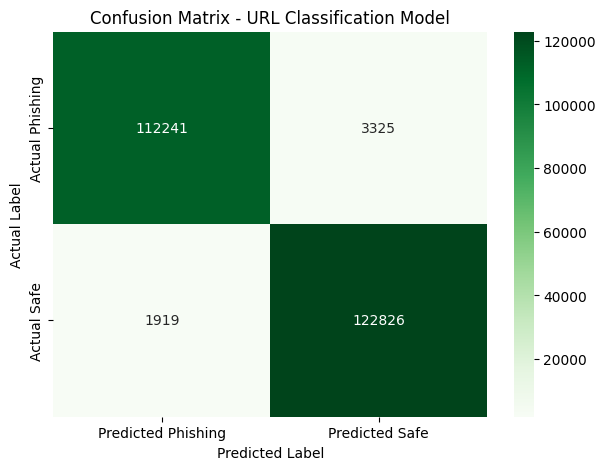

In [ ]:
# 4. Visualizing the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Phishing', 'Predicted Safe'],
            yticklabels=['Actual Phishing', 'Actual Safe'])
plt.title('Confusion Matrix - URL Classification Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# 1. Get the final Accuracy from the training history
train_acc = history.history['accuracy'][-1]

# 2. Extract values from the Confusion Matrix
# Note: cm[row][column] -> row is actual, column is predicted
# Based on your heatmap: [0,0]=TN, [0,1]=FP, [1,0]=FN, [1,1]=TP
tn, fp, fn, tp = cm.ravel()

# 3. Calculate Rates
tpr = tp / (tp + fn)  # True Positive Rate (Sensitivity/Recall)
tnr = tn / (tn + fp)  # True Negative Rate (Specificity)
fpr = fp / (fp + tn)  # False Positive Rate
fnr = fn / (fn + tp)  # False Negative Rate

# 4. Calculate overall Test Accuracy
test_acc = (tp + tn) / (tp + tn + fp + fn)

print("="*40)
print(f"{'METRIC':<20} | {'VALUE':<10}")
print("-"*40)
print(f"{'Training Accuracy':<20} | {train_acc:.4f}")
print(f"{'Testing Accuracy':<20} | {test_acc:.4f}")
print(f"{'TPR (Sensitivity)':<20} | {tpr:.4f}")
print(f"{'TNR (Specificity)':<20} | {tnr:.4f}")
print(f"{'FPR (Fall-out)':<20} | {fpr:.4f}")
print(f"{'FNR (Miss Rate)':<20} | {fnr:.4f}")
print("="*40)

METRIC               | VALUE     
----------------------------------------
Training Accuracy    | 0.9845
Testing Accuracy     | 0.9782
TPR (Sensitivity)    | 0.9846
TNR (Specificity)    | 0.9712
FPR (Fall-out)       | 0.0288
FNR (Miss Rate)      | 0.0154


In [ ]:
import tensorflow as tf
import pickle

# 1. Load the existing Keras model
model_path = 'best_phishing_model (3).h5'
model = tf.keras.models.load_model(model_path)

# 2. Define the destination path
pickle_path = 'best_phishing_model.pkl'

# 3. Save the model object to a pickle file
with open(pickle_path, 'wb') as f:
    pickle.dump(model, f)

print(f"Model successfully converted and saved to {pickle_path}")

Model successfully converted and saved to best_phishing_model.pkl
